# Dataset curation

Sort, filter, group, dedupe, and flag structures to curate better training subsets.
Decisions (keep / remove + reason) persist to `data/cache/curation_decisions.json` and
survive across sessions. Everything runs on the cached subset built by
`python -m blockgen.data.build_cache`.

Workflow: **inspect → group → flag → save → apply**.


## Load

In [1]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from blockgen.curation import Curator

cur = Curator.from_cache(max_dim=24)
cur.load_decisions()      # resume any earlier session
cur.summary()

structures: 2892
  n_blocks                 min    8.00  median  520.00  p90 1712.80  max 4096.00
  max_dim                  min    3.00  median   16.00  p90   23.00  max   24.00
  density                  min    0.03  median    0.39  p90    0.69  max    1.00
  n_block_types            min    1.00  median   12.00  p90   27.00  max   58.00
  n_components             min    1.00  median    1.00  p90    4.00  max   65.00
  largest_component_frac   min    0.06  median    1.00  p90    1.00  max    1.00
  top dominant materials: planks(331), wool(212), stonebrick(210), stone(204), dirt(189), quartz_block(187), stone_slab(146), cobblestone(143)
  flagged so far: 0  (remove=0, keep=0)


## Inspect — sort & filter by any feature
Features per structure: `sx,sy,sz, max_dim, n_blocks, density, footprint, height, n_block_types, dominant_block, dominant_frac, n_components, largest_component_frac`.

In [2]:
# Biggest / densest first
cur.table(sort_by="n_blocks", limit=15)

index | path            | sx | sy | sz | n_blocks | density | n_block_types | n_components | dominant_block       
------+-----------------+----+----+----+----------+---------+---------------+--------------+----------------------
2350  | 7352.schematic  | 16 | 16 | 16 | 4096     | 1.000   | 3             | 1            | gold_block           
1358  | 2919.schematic  | 18 | 21 | 18 | 4068     | 0.598   | 3             | 1            | stained_hardened_clay
2873  | 9920.schematic  | 23 | 23 | 19 | 3929     | 0.391   | 36            | 8            | dirt                 
1158  | 1894.schematic  | 16 | 23 | 16 | 3925     | 0.667   | 26            | 1            | stone                
1362  | 2930.schematic  | 20 | 22 | 20 | 3886     | 0.442   | 14            | 1            | stone_slab           
1075  | 1662.schematic  | 24 | 15 | 23 | 3871     | 0.468   | 17            | 2            | dirt                 
1333  | 2808.schematic  | 17 | 16 | 17 | 3834     | 0.829   | 11            | 1 

In [3]:
# Filtering returns a *view* (cur.<...>.indices maps back to the originals).
buildings = cur.filter(min_blocks=60, max_components=2, min_block_types=4)
tiny      = cur.filter(max_blocks=12)
monotype  = cur.filter(max_block_types=1)
print("building-like:", len(buildings), "| tiny:", len(tiny), "| single-material:", len(monotype))
buildings.table(sort_by="density", limit=8)

building-like: 2177 | tiny: 10 | single-material: 48
index | path            | sx | sy | sz | n_blocks | density | n_block_types | n_components | dominant_block
------+-----------------+----+----+----+----------+---------+---------------+--------------+---------------
529   | 12066.schematic | 3  | 6  | 6  | 108      | 1.000   | 12            | 1            | concrete      
2202  | 6701.schematic  | 18 | 19 | 1  | 342      | 1.000   | 4             | 1            | bedrock       
2203  | 6702.schematic  | 1  | 14 | 15 | 210      | 1.000   | 4             | 1            | wool          
2204  | 6703.schematic  | 1  | 14 | 13 | 182      | 1.000   | 4             | 1            | wool          
2214  | 6722.schematic  | 9  | 5  | 6  | 270      | 1.000   | 6             | 1            | bedrock       
2755  | 9443.schematic  | 4  | 7  | 3  | 84       | 1.000   | 13            | 1            | quartz_block  
2369  | 747.schematic   | 3  | 7  | 5  | 104      | 0.991   | 15            | 1    

## Visual review — contact sheets
Render a grid of thumbnails for any set of indices.

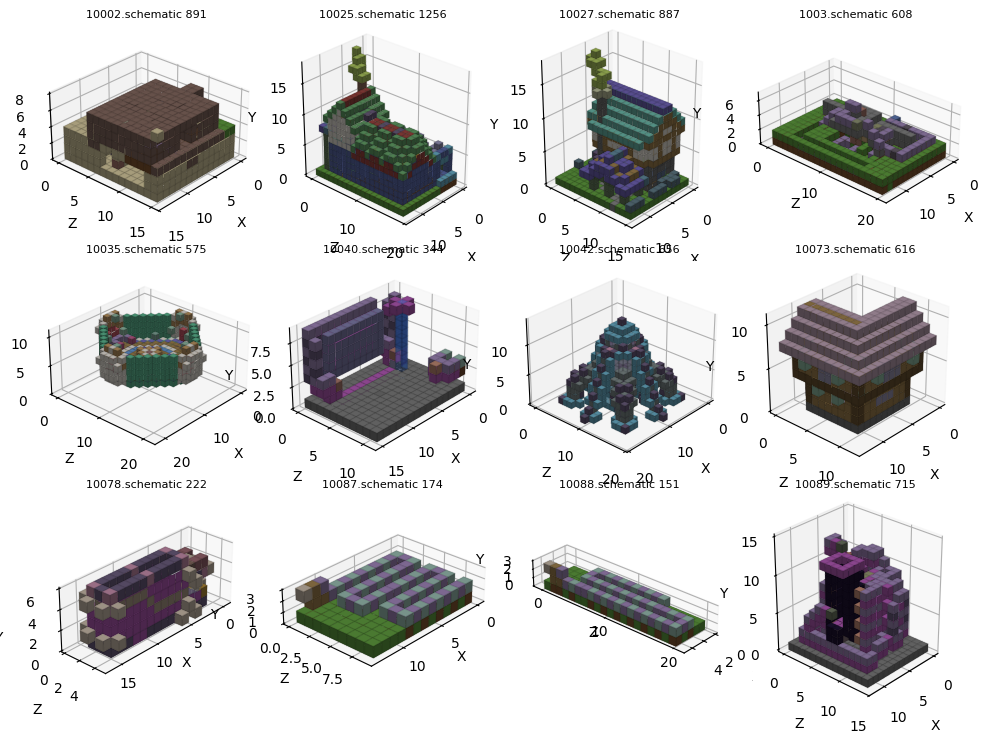

In [4]:
fig = cur.contact_sheet(buildings.indices[:12], cols=4); plt.show()

## Group similar structures
Two ways: **shape similarity** (occupancy IoU, GPU-accelerated) and **feature clusters** (k-means).

59 near-duplicate groups; extras to drop = 88


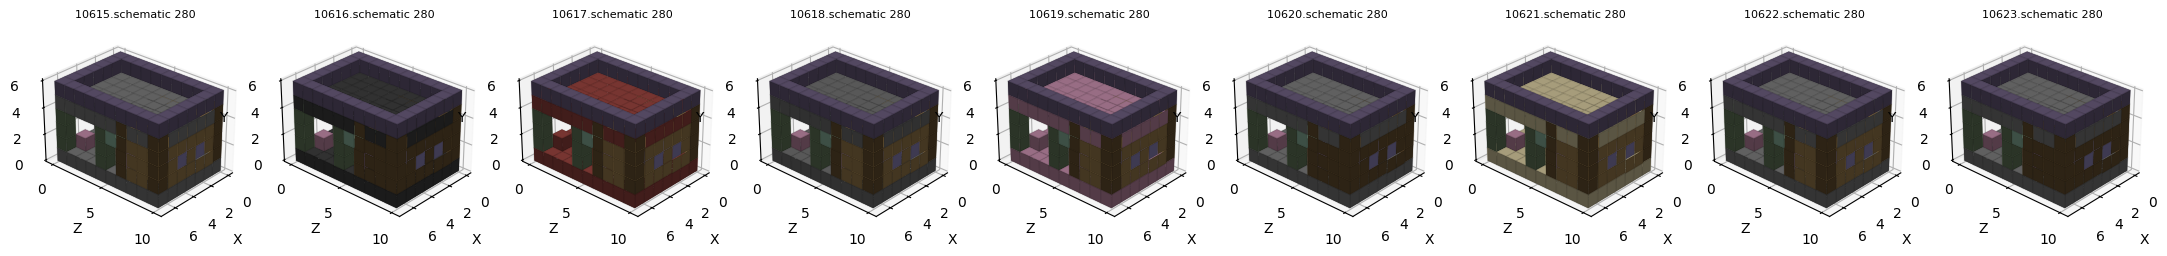

In [5]:
# Near-duplicates (high IoU) — prime removal candidates.
dups = cur.find_duplicates(iou_threshold=0.95)
print(f"{len(dups)} near-duplicate groups; extras to drop = {sum(len(g)-1 for g in dups)}")
if dups:
    cur.show_group(dups[0], cols=len(dups[0])); plt.show()   # inspect the largest group

In [6]:
# Looser shape families (tune the threshold).
families = [g for g in cur.group_by_similarity(iou_threshold=0.6) if len(g) > 2]
print("shape families (size>2):", len(families), "| sizes:", sorted((len(g) for g in families), reverse=True)[:10])

shape families (size>2): 45 | sizes: [79, 65, 59, 34, 28, 25, 22, 10, 9, 9]


cluster 0: n= 246  e.g. 1268 blocks, density 0.7584, dominant dirt
cluster 1: n= 643  e.g. 891 blocks, density 0.5304, dominant sandstone
cluster 2: n= 445  e.g. 1665 blocks, density 0.2455, dominant stonebrick
cluster 3: n= 300  e.g. 427 blocks, density 0.1981, dominant quartz_block
cluster 4: n= 324  e.g. 660 blocks, density 0.75, dominant dirt
cluster 5: n=  73  e.g. 651 blocks, density 0.1225, dominant planks
cluster 6: n= 538  e.g. 73 blocks, density 0.2607, dominant wool
cluster 7: n= 323  e.g. 1256 blocks, density 0.2825, dominant monster_egg


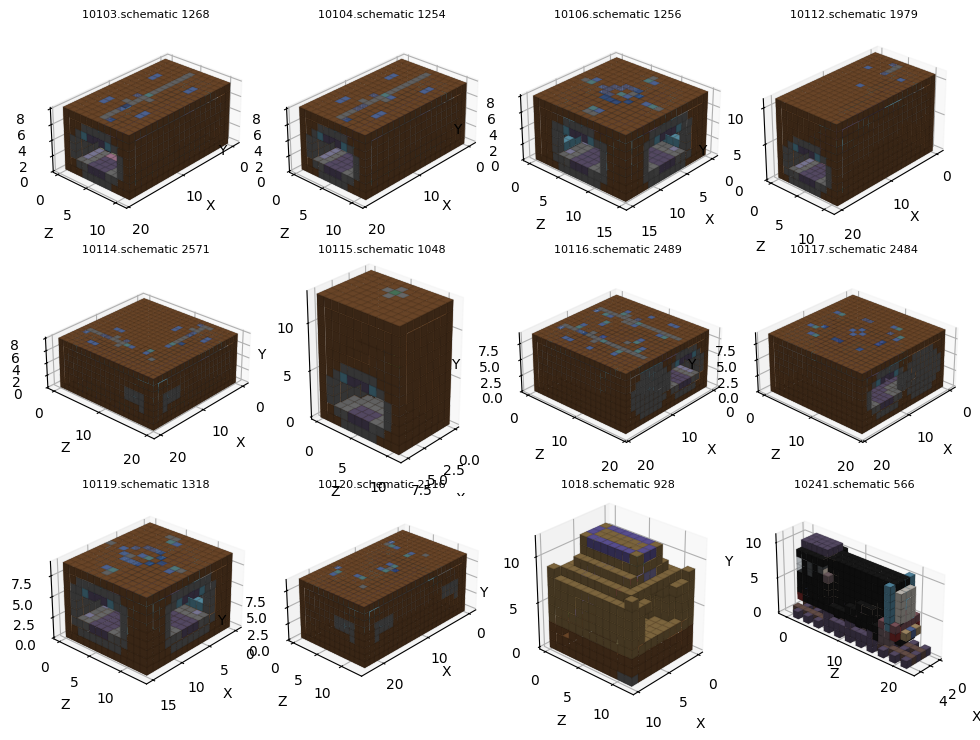

In [7]:
# Feature clusters — coarse groupings by size/density/material composition.
clusters = cur.cluster_features(k=8)
for c, group in enumerate(clusters):
    rep = cur.features[group[0]]
    print(f"cluster {c}: n={len(group):4d}  e.g. {rep['n_blocks']} blocks, "
          f"density {rep['density']}, dominant {rep['dominant_block'].split(':')[-1]}")
# Visualize one cluster:
cur.show_group(clusters[0][:12], cols=4); plt.show()

## Flag for removal / keeping

`mark_remove(indices, reason)` and `mark_keep(indices, reason)` record decisions.
Pass the `.indices` of any filtered view, or members of a group.


In [8]:
# Example pass — adjust to taste, then re-run:
if dups:
    cur.mark_remove([i for g in dups for i in g[1:]], reason="near-duplicate")  # keep 1 per group
cur.mark_remove(tiny.indices, reason="too small")
cur.mark_remove(cur.filter(predicate=lambda r: r["n_components"] >= 5 and r["largest_component_frac"] < 0.4).indices,
                reason="fragmented")
print("flagged remove:", len(cur.remove_list()))

flagged remove: 107


## Save & apply
Persist decisions, then materialize the curated set for training.

In [9]:
cur.save_decisions()                 # -> data/cache/curation_decisions.json
kept = cur.apply()                   # structures minus 'remove' (or only 'keep' if any keeps set)
print(f"curated set: {len(kept)} of {len(cur)} structures")

# `kept` is a list[Structure] ready to feed the training functions, e.g.:
#   from blockgen.utils.serialize import build_block_vocab
#   vocab = build_block_vocab(kept, max_dim=24)
#   from blockgen.training.train_ar import train_ar; train_ar(kept, vocab)
# Or export a path list for dataset_from_list_file:
# cur.export_keep_list("data/cache/curated_paths.txt")

curated set: 2785 of 2892 structures


# Metadata-powered curation (labeled cache)

The `data/raw` files don't map to any metadata, but the dataset's
`schematics/*.tfrecords` pair every schematic with its **source url** → rich
metadata (title, category, tags, description, popularity). Build the labeled
cache once, then curate with all of that available.

    python -m blockgen.data.tfrecord_dataset --max-dim 24   # one-time, ~minutes


In [10]:
import os
from blockgen.data.tfrecord_dataset import TFCacheConfig, build_labeled_cache, cache_path
cfg = TFCacheConfig(max_dim=24)
if not os.path.exists(cache_path(cfg)):
    print(build_labeled_cache(cfg))

lab = Curator.from_labeled_cache(max_dim=24)
lab.load_decisions()
lab.summary()                 # now shows category + metadata coverage
print(lab.categories())

loaded 5866 structures, 5866 with metadata (100%)
structures: 5866
  n_blocks                 min    8.00  median  406.00  p90 1600.00  max 4096.00
  max_dim                  min    3.00  median   16.00  p90   23.00  max   24.00
  density                  min    0.02  median    0.35  p90    0.67  max    1.00
  n_block_types            min    1.00  median   12.00  p90   26.00  max   81.00
  n_components             min    1.00  median    1.00  p90    5.00  max  103.00
  largest_component_frac   min    0.08  median    1.00  p90    1.00  max    1.00
  top dominant materials: wool(791), planks(526), stone_slab(518), stone(423), dirt(358), sandstone(292), grass(279), stained_hardened_clay(272)
  with metadata: 5866/5866
  top categories: Land Structure Map(1723), Redstone Device Map(1287), 3D Art Map(1264), Other Map(477), Air Structure Map(427), Complex Map(126), Pixel Art Map(125), Piston Map(120)
  flagged so far: 0  (remove=107, keep=0)
[('Land Structure Map', 1723), ('Redstone Device M

## Isolate an object type by metadata
Combine free-text `search` with category/feature filters to carve out one kind of build (e.g. houses).

search('house'): 1174
buildable houses: 714


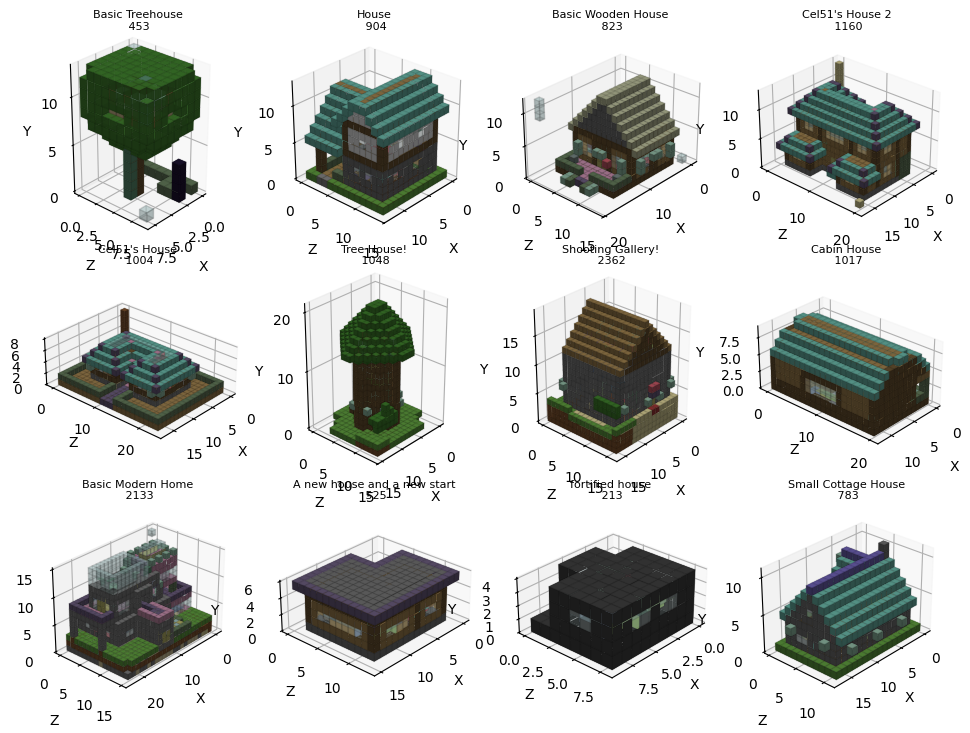

In [11]:
# Free-text search hits anything with 'house' in title/description/tags...
print("search('house'):", len(lab.search("house")))
# ...but that includes pixel-art/map-art. Constrain to buildable structures:
houses = (lab.search("house")
             .filter(category_in=["Land Structure Map", "Air Structure Map",
                                   "Other Map", "Complex Map"])
             .filter(min_blocks=60, max_components=3, min_block_types=3))
print("buildable houses:", len(houses))
fig = lab.contact_sheet(houses.indices[:12], cols=4); plt.show()

## Keep material/color variations, drop only true copies

Many "duplicates" are the *same build in different woods/wools* — valuable
variety, not junk. `find_variant_groups` surfaces them; `dedupe_keep_variants`
removes only exact (same-shape **and** same-palette) copies.


exact-dup groups: 27 (extras 29)  |  variant groups (KEEP): 58


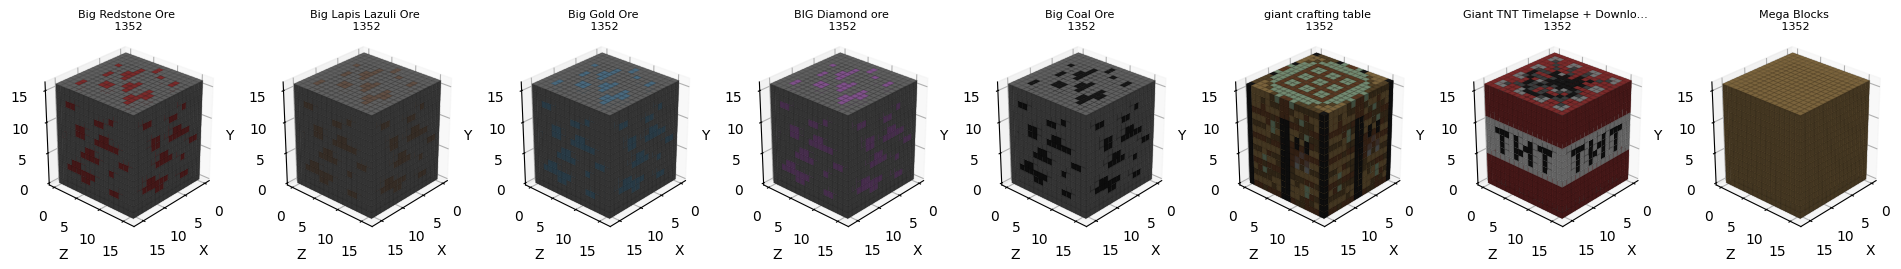

flagged true-duplicate extras for removal: 29


In [12]:
exact = lab.find_exact_duplicates(0.95)
variants = lab.find_variant_groups(0.9)
print(f"exact-dup groups: {len(exact)} (extras {sum(len(g)-1 for g in exact)})  |  variant groups (KEEP): {len(variants)}")
if variants:
    lab.show_group(variants[0], cols=len(variants[0])); plt.show()   # same shape, different materials
n = lab.dedupe_keep_variants(reason="exact-duplicate")
print("flagged true-duplicate extras for removal:", n)

## Auto-mark a reliable seed subset by popularity
Highly-diamonded / downloaded builds are usually clean and complete — a good starting training set.

In [ ]:
n = lab.auto_mark_reliable(min_diamonds=10, min_downloads=100)
print("auto-marked 'keep' (popular):", n)
lab.save_decisions()

## Build & export a named subset for training
Materialize a single-category subset (e.g. houses) and hand it straight to the models.

In [ ]:
houses.export_keep_list("data/cache/subset_houses.txt")
house_structs = Curator.from_structures([houses.structures[i] for i in houses.indices],
                                         metadata=lab.metadata).apply()
print(f"house subset: {len(house_structs)} structures -> data/cache/subset_houses.txt")
# e.g.:  from blockgen.training.train_ar import train_ar
#        from blockgen.utils.serialize import build_block_vocab
#        v = build_block_vocab(house_structs, max_dim=24); train_ar(house_structs, v)

## Notes
- Decisions are keyed by source path (here the url), so they're stable across reloads.
- `cur.clear_marks(indices)` undoes flags; re-run `summary()` to see counts.
- Quick terminal pass: `python -m blockgen.curation.curate --labeled` (or omit `--labeled` for the raw cache).


## Curated cross-corpus HOUSE dataset (2026-07-06)

`blockgen/curation/houses.py` pools GrabCraft `*-houses` + 3D-Craft + house-tagged text2mc
(remapped to the legacy vocab by `utils/block_remap.py`), quality-filters (incl. the
**enclosed-air house-ness gate**), dedupes, and caches. Rebuild:

    python -m blockgen.curation.houses --max-dim 32

Showcase grids (real Minecraft textures, headless): `python -m blockgen.renderer.grid --houses 32 --rows 8 --cols 12 --out outputs/figures/houses_32_grid.png`


In [ ]:
from blockgen.curation.houses import load_house_structures
from blockgen.renderer.grid import render_grid
import matplotlib.pyplot as plt

houses, manifest = load_house_structures(max_dim=32)
print(len(houses), "houses |", manifest["report"]["final_by_corpus"])

# Textured mini-grid inline (uses data/textures/vanilla; falls back to matplotlib tiles)
img = render_grid(houses[:12], cols=6, tile_px=160)
plt.figure(figsize=(14, 5)); plt.imshow(img); plt.axis("off"); plt.show()

# Curate further with the usual tools:
# from blockgen.curation import Curator
# cur = Curator.from_structures(houses, max_dim=32)
# cur.summary()